# Using the mode as a statistic in Python

## Setup - describing a distribution

There are three main statistics we can use to describe a distribution:
- **mean:** the average of all values
$$\textrm{Mean} = \frac{\textrm{Sum of all values}}{\textrm{Number of values}}$$
- **median:** the middle value in a sorted dataset with $n$ values (i.e., the 50th percentile)
$$\textrm{Median}(x) = 
    \begin{cases}
        x_{(n+1)/2} & n \textrm{ is odd}\\
        \frac{\left(x_{(n/2)} + x_{((n/2) + 1)}\right)}{2} & n \textrm{ is even}
    \end{cases}
$$
- **mode:** the most frequent value in a dataset

### Normal Distribution
In a normal (Gaussian) distribution, all three statistics are the same value. I show this below with a distribution of integer values.

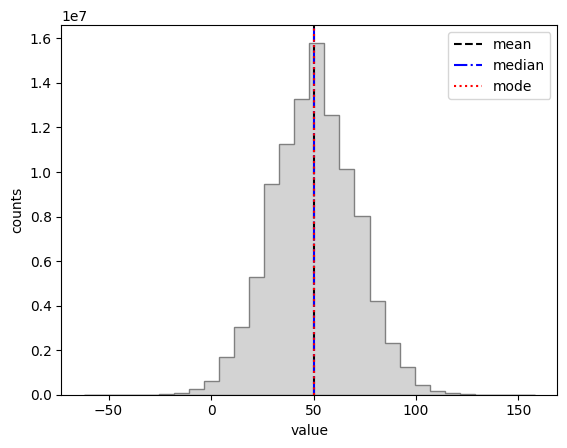

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

# randomly generate a normal distribution of integers
# I give a seed value in this notebook so the random generator gives reproducible results
rng = np.random.default_rng(seed=1234)
int_data = rng.normal(loc=50, scale=20, size=100000000).round()

# calculate the mean, median, mode
mean = int_data.mean()
median = np.median(int_data)
mode, _ = scipy.stats.mode(int_data)

# plot the distribution and lines showing the three stats
plt.hist(int_data, bins=30, color='lightgray', edgecolor='gray', histtype='stepfilled');
plt.axvline(mean, color='black', ls='--', label='mean')
plt.axvline(median, color='blue', ls='-.', label='median')
plt.axvline(mode, color='red', ls=':', label='mode')
plt.legend()
plt.ylabel('counts')
plt.xlabel('value')
plt.show()

All three statistics are equal within a normal distribution, so typically the mean is used since it's the simplest to calculate. Furthermore, the mean is usually very informative because the world is filled with randomness and random distributions, and the *central limit theorem* states that the distribution of a random variable becomes a normal distribution as the number of samples increses. Common examples of normal distributions are the birthweights of newborn babies and heights of adult women in the United States.

### Asymmetric Distribution
For other distributions, the median or mode may provide more accurate information. I demonstrate this for an asymmetric distribution below.

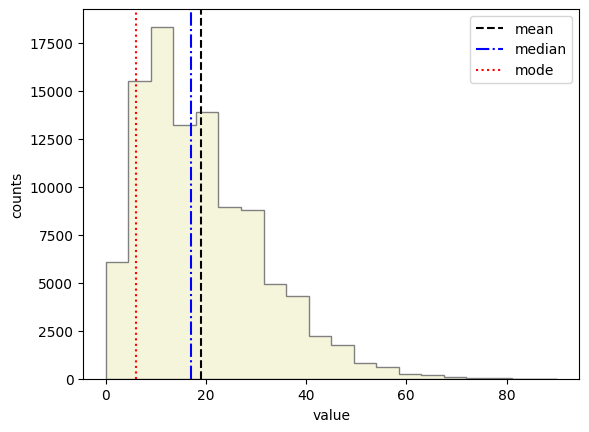

In [2]:
# randomly generate an asymmetrical distribution of integers
rng = np.random.default_rng(seed=1234)
asymm = scipy.stats.skewnorm.rvs(20, loc=3, scale=20, size=100000).round()

# calculate the mean, median, mode
mean = asymm.mean()
median = np.median(asymm)
mode, _ = scipy.stats.mode(asymm)

# plot the distribution and lines showing the three stats
plt.hist(asymm, bins=20, color='beige', edgecolor='gray', histtype='stepfilled');
plt.axvline(mean, color='black', ls='--', label='mean')
plt.axvline(median, color='blue', ls='-.', label='median')
plt.axvline(mode, color='red', ls=':', label='mode')
plt.legend()
plt.ylabel('counts')
plt.xlabel('value')
plt.show()

The mean is easily influenced by outliers since all values in the distribution are considered equally (a weighted mean could be used if you know the weights of each value). The mode can be very informative to describe a distribution since it describles the peak of the distribution. However, the mode can be misleading or additional data processing is required if there is a sharp spike in values greater than the "peak" of the distribution. Since the median is more resistant to extreme values, and it represents the 50th percentile value of the sample, it is commonly adopted as the reported or published statistic to describe a distribution.

## The issue with `scipy.stats.mode`

You may have noticed I rounded the distributions to the nearest whole number when I generated them above. First, let's see what happens when I don't round the distribution, then I'll explain.

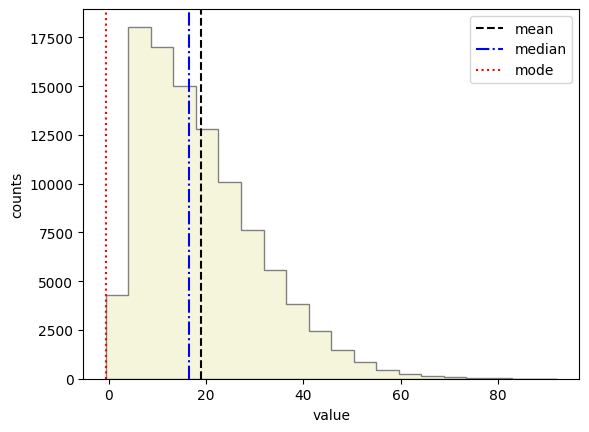

In [3]:
# randomly generate an asymmetrical distribution of integers
rng = np.random.default_rng(seed=1234)
# ...leaving off the `round()` method from the end
asymm = scipy.stats.skewnorm.rvs(20, loc=3, scale=20, size=100000)

# calculate the mean, median, mode
mean = asymm.mean()
median = np.median(asymm)
mode, _ = scipy.stats.mode(asymm)

# plot the distribution and lines showing the three stats
plt.hist(asymm, bins=20, color='beige', edgecolor='gray', histtype='stepfilled');
plt.axvline(mean, color='black', ls='--', label='mean')
plt.axvline(median, color='blue', ls='-.', label='median')
plt.axvline(mode, color='red', ls=':', label='mode')
plt.legend()
plt.ylabel('counts')
plt.xlabel('value')
plt.show()

The mean and median are pretty much the same (rounding causes slight deviations), however, the mode is clearly not at the peak where we expect. 

*Why is the mode wrong?* And *why is it at zero?*

The answer to both questions lies with how the mode is calculated by `scipy.stats`. Since the mode is the most frequent value of the dataset, the function searches for duplicate values and returns the value with the highest occurrence. If multiple values occur the same number of times, the function returns the first value. The distribution above is continuous and entirely consists of unique values, therefore, `scipy.stats.mode` returns the first value in the distribution (near zero).

## How to find the mode of a continuous distribution?

The following are three examples of ways to find the mode of a continuous distribution. Each has its tradeoffs between simplicity of the method and precision of the final result.

### 1. Use `scipy.stats.mode` while rounding the input array (like I did when I first introduced the asymmetric distribution)

Here's a function that takes in an array and the desired precision for the rounding and returns a mode. The higher the rounding precision (i.e., the more decimal places we keep), the less likely the returned mode will be correct.

In [4]:
def rounded_mode(arr, precision=0):
    mode, _ = scipy.stats.mode(np.array(arr).round(precision))
    return mode

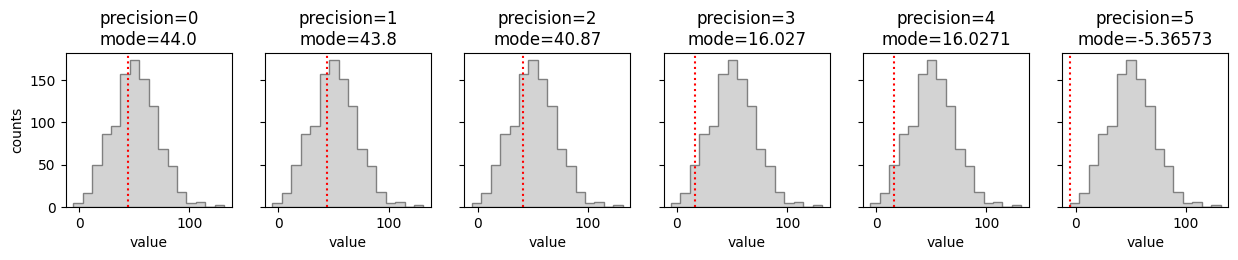

In [5]:
# generate the continuous data
rng = np.random.default_rng(seed=1234)
data = rng.normal(loc=50, scale=20, size=1000)

# plot results from a range of precisions
precisions = np.arange(6)
fig, axes = plt.subplot_mosaic(
    [precisions.tolist()],
    figsize=(15, 2),
    sharey=True,
    )

for p in precisions:
    ax = axes[p]
    ax.hist(data, bins=16, color='lightgray', edgecolor='gray', histtype='stepfilled')
    ax.set_xlabel("value")
    mode = rounded_mode(data, precision=p)
    ax.axvline(mode, linestyle=':', color='red')
    ax.set_title(f"precision={p}\nmode={mode}")

axes[0].set_ylabel("counts")
plt.show()

I generated a normal distribution with a mean of 50 and a standard deviation of 20, so the correct mode should be 50. In this example, the higher the rounding precision, the farther away the result is from the true mode. This simple method may improve in accuracy for distributions with larger numbers of samples.

### 2. Bin the data with `np.histogram` and find the bin with the largest number of counts

Here's a function that takes an array and the desired number of bins and returns the bin containing the largest number of counts. Fewer bins won't be precise enough to return the correct mode in wide datasets, and many bins may return a local maximum instead of the true peak.

In [6]:
def binned_mode(arr, bins):
    counts, bin_values = np.histogram(arr, bins=bins)
    return bin_values[np.argmax(counts)]

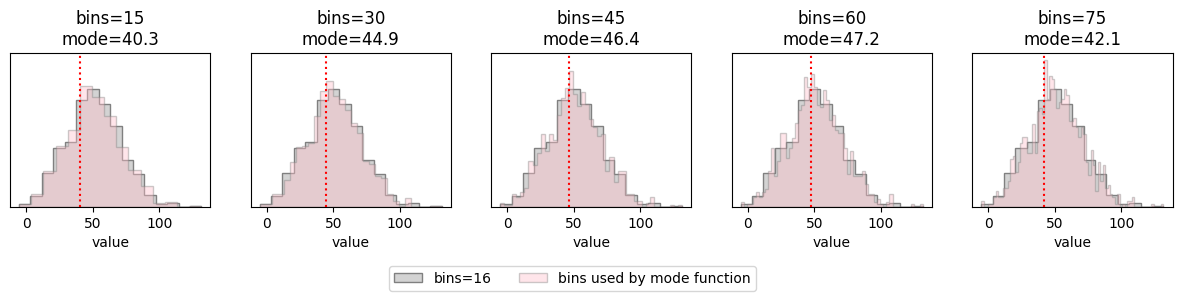

In [7]:
from matplotlib.patches import Patch

# generate the continuous data
rng = np.random.default_rng(seed=1234)
data = rng.normal(loc=50, scale=20, size=1000)

# plot results for a range of bins
bins = np.arange(15, 90, 15)
fig, axes = plt.subplot_mosaic(
    [bins.tolist()],
    figsize=(15, 2),
    sharey=True,
    )

for b in bins:
    ax = axes[b]
    # use `density=True` to put all histograms on the same scale
    ax.hist(data, bins=16, color='lightgray', edgecolor='gray', histtype='stepfilled', density=True)
    ax.hist(data, bins=b, color='pink', edgecolor='gray', histtype='stepfilled', alpha=0.4, density=True)
    ax.set_xlabel("value")
    mode = binned_mode(data, bins=b)
    ax.axvline(mode, linestyle=':', color='red')
    ax.set_title(f"bins={b}\nmode={mode:.1f}")
    ax.tick_params(left=False, labelleft=False)

# axes[bins[0]].set_ylabel("counts")
fig.legend(
    handles=[
        Patch(
            facecolor='lightgray',
            edgecolor='gray',
            alpha=1,
            label="bins=16"
        ),
        Patch(
            facecolor='pink',
            edgecolor='gray',
            alpha=0.4,
            label="bins used by mode function"
        )
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)
plt.show()

In each panel I show the same normal distribution (mean of 50, std of 20) with 16 bins (gray) overlaid with histograms with the number of bins used to calculate each mode (pink). In this example, the number of bins that gets us closest to the correct mode is 60. This number will likely be different depending on how large and how wide the dataset is.

### 3. Smooth the distribution with a Gaussian kernel and find the peak

Here's a function that takes an array and returns the peak value of the fitted Gaussian kernel density estimate. The function will fit a Gaussian kernel to the dataset which should increase the precision of our mode result but at the cost of added complexity.

In [8]:
def kde_mode(arr):
    kernel = scipy.stats.gaussian_kde(arr)
    x = np.linspace(arr.min(), arr.max(), 1000)
    return x[np.argmax(kernel.evaluate(x))]

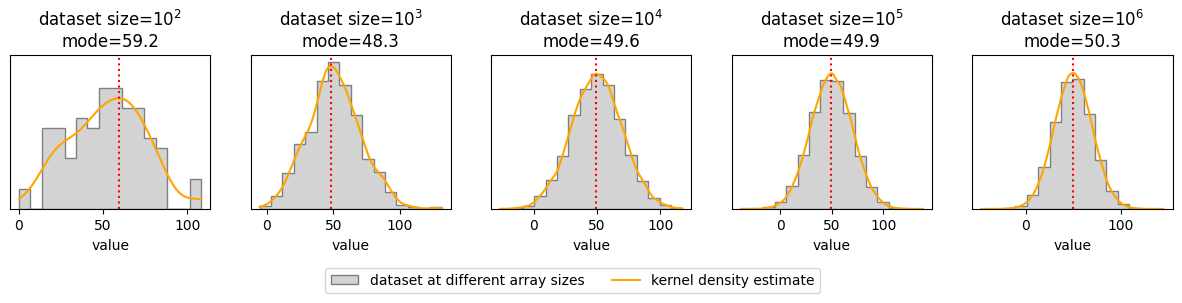

In [9]:
from matplotlib.lines import Line2D

# plot results for a range of dataset sizes
sizes = 10**np.arange(2, 7)
fig, axes = plt.subplot_mosaic(
    [sizes.tolist()],
    figsize=(15, 2),
    sharey=True,
    )

rng = np.random.default_rng(seed=1234)

for s in sizes:
    # generate the data at each array size
    data = rng.normal(loc=50, scale=20, size=s)
    # calculate the kernel density estimate for the plot
    kde = scipy.stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 1000)

    ax = axes[s]
    # use `density=True` to put all histograms on the same scale
    ax.hist(data, bins=16, color='lightgray', edgecolor='gray', histtype='stepfilled', density=True)
    ax.plot(x, kde.evaluate(x), color='orange')
    ax.set_xlabel("value")
    mode = kde_mode(data)
    ax.axvline(mode, linestyle=':', color='red')
    ax.set_title(f"dataset size=$10^{{{int(np.log10(s))}}}$\nmode={mode:.1f}")
    ax.tick_params(left=False, labelleft=False)

# axes[bins[0]].set_ylabel("counts")
fig.legend(
    handles=[
        Patch(
            facecolor='lightgray',
            edgecolor='gray',
            alpha=1,
            label="dataset at different array sizes"
        ),
        Line2D(
            [],
            [],
            color='orange',
            label="kernel density estimate"
        )
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)
plt.show()

The KDE mode function doesn't take any additional arguments besides the dataset array, so I show how the mode might change for different sized datasets. In this case, the mode is generally more accurate (closer to 50) as the dataset size increases. The slight deviation at an array length of $10^6$ is likely due to random variations in the dataset generation. It's worth mentioning that this method is by far the slowest in runtime out of the three methods, so it's worth taking that into consideration when weighing the pros and cons of this method (especially for larger datasets).

## Summary

The mode can be a powerful statistic to describe a dataset, however, finding the mode of a continuous distribution or a small dataset can be tricky with common methods like `scipy.stats.mode`. I gave three examples of how to calculate the mode of a continuous distribution: rounding the dataset before using `scipy.stats.mode`, binning the dataset with `np.histogram` and finding the bin with the highest number of counts, and fitting a Gaussian kernel density estimate to the dataset and finding the peak. Each example comes with a tradeoff between simplicity (and computational complexity) and precision of the mode result; some methods might need more fine-tuning for better accuracy.